## Model -1 for Home A (Simulated and Real Test Set)
#### Without hidden-dim layers

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load and preprocess data
data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_df = pd.read_csv(data_path)

# Extract features (X) and target labels (y) from the loaded data
X = data_df.drop(columns=["Label"])  # Drop the label column
y = data_df["Label"]  

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X)
#X_test_scaled = scaler.transform(X_test)

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (35040, 1380)
y shape: (35040,)


In [5]:
# Define the autoencoder model with deep layers
input_dim = X_train_scaled.shape[1]
encoding_dim = 64
hidden_dim = 32

input_layer = Input(shape=(input_dim,))
encoder_layer1 = Dense(encoding_dim * 2, activation='relu')(input_layer)
encoder_layer2 = Dense(encoding_dim, activation='relu')(encoder_layer1)
decoder_layer2 = Dense(encoding_dim * 2, activation='relu')(encoder_layer2)
decoder_layer1 = Dense(input_dim, activation='sigmoid')(decoder_layer2)

autoencoder = Model(input_layer, decoder_layer1)
autoencoder.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder on the training set
autoencoder.fit(X_train_scaled, X_train_scaled,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.1,  # Using a portion of training data for validation
                callbacks=[early_stopping])  # Adding the early stopping callback


Epoch 1/100
986/986 [==============================] - 6s 5ms/step - loss: 0.0174 - val_loss: 0.0080
Epoch 2/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0055 - val_loss: 0.0046
Epoch 3/100
986/986 [==============================] - 5s 5ms/step - loss: 0.0040 - val_loss: 0.0039
Epoch 4/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0036 - val_loss: 0.0036
Epoch 5/100
986/986 [==============================] - 5s 5ms/step - loss: 0.0033 - val_loss: 0.0033
Epoch 6/100
986/986 [==============================] - 5s 5ms/step - loss: 0.0031 - val_loss: 0.0032
Epoch 7/100
986/986 [==============================] - 5s 5ms/step - loss: 0.0030 - val_loss: 0.0031
Epoch 8/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0029 - val_loss: 0.0031
Epoch 9/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 10/100
986/986 [==============================] - 5s 5ms/step - loss: 0.0028 - val_lo

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1380)]            0         
                                                                 
 dense (Dense)               (None, 128)               176768    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 128)               8320      
                                                                 
 dense_3 (Dense)             (None, 1380)              178020    
                                                                 
Total params: 371,364
Trainable params: 371,364
Non-trainable params: 0
_________________________________________________________________
1095/1095 [==============================] - 3s 3ms/ste

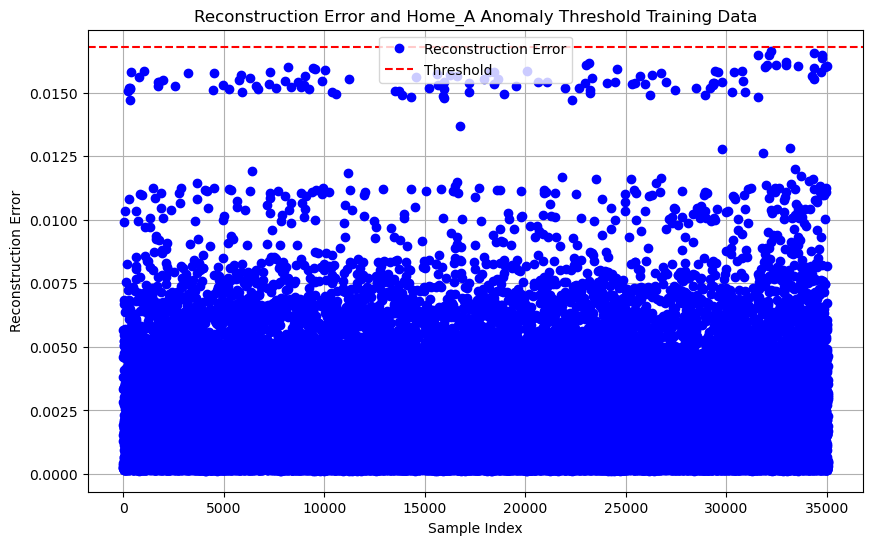

In [10]:
# Print the model summary
autoencoder.summary()

# Calculate reconstruction error for test data
train_predictions = autoencoder.predict(X_train_scaled)
reconstruction_error = np.mean(np.square(X_train_scaled - train_predictions), axis=1)

# Print reconstruction errors
print("Reconstruction Errors:")
print(reconstruction_error)

# Calculate threshold using Median Absolute Deviation (MAD)
median = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median))
threshold = median + (12 * mad)  # Adjust the multiplier as needed

print("Threshold:", threshold)

# Print and save the trained autoencoder model
model_path = "trained_autoencoder_model.h5"
autoencoder.save(model_path)
print("Model saved at:", model_path)

# Save the threshold
threshold_path = "trained_threshold.npy"
np.save(threshold_path, threshold)
print("Threshold saved at:", threshold_path)

# Visualize the reconstruction error and threshold
plt.figure(figsize=(10, 6))
# plt.figure(figsize=(5, 3))
plt.plot(reconstruction_error, marker='o', linestyle='', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Home_A Anomaly Threshold Training Data')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_Training.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_rec-err_thr.eps',bbox_inches='tight')
plt.show()


In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Data preprocessing
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)


10/10 [==============================] - 0s 2ms/step
Threshold saved at: 0.016792385427469046
Anomalous Data Indices:
[ 30  42  57  72  73  91  95 102 137 159 187 190 200 256 266 286]


In [14]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

Accuracy: 0.5586206896551724
Precision: 1.0
Recall: 0.1111111111111111
TNR: 1.0
FPR: 0.0
FNR: 0.8888888888888888
F1 Score: 0.19999999999999998
ROC AUC: 0.7603215372907154


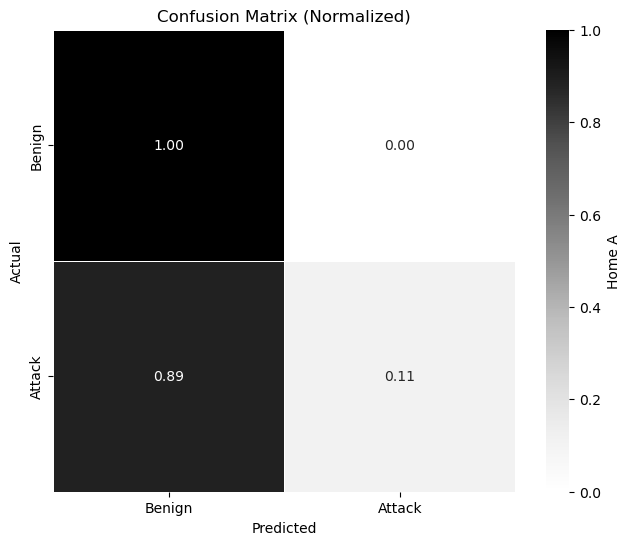

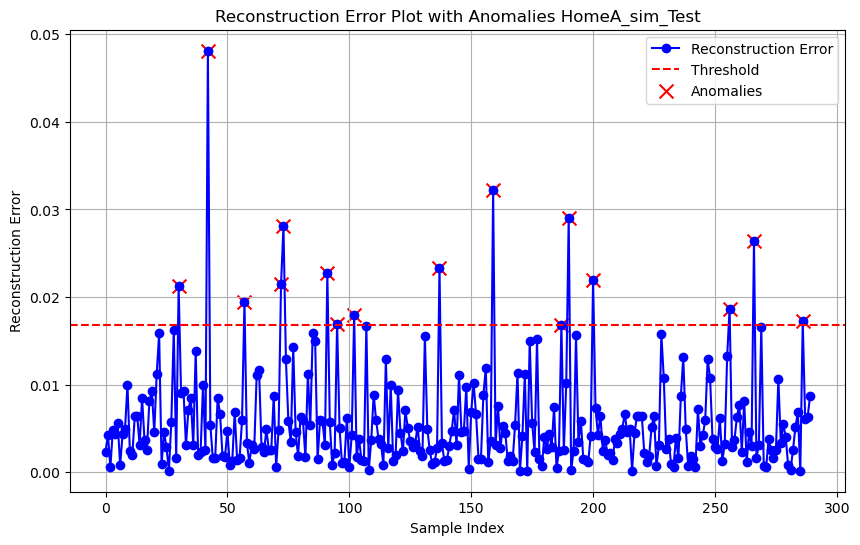

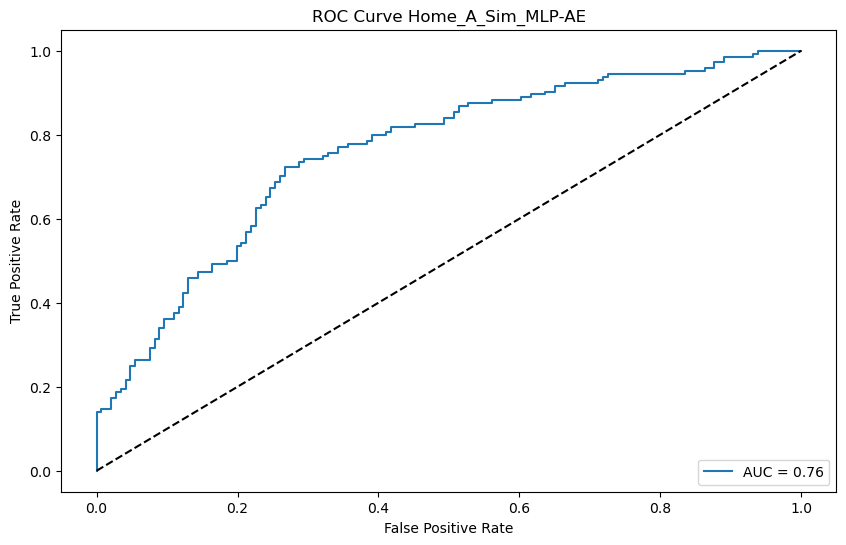

In [15]:
import seaborn as sns
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

import seaborn as sns

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, anomalies)

# Normalize the confusion matrix
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
# sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap='Greys', linewidths=0.5, square=True, cbar_kws={'label': 'Home A'}
sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
            cbar_kws={'label': 'Home A'},
            xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Normalized)')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_anomalies_sim_cm.png',bbox_inches='tight')
# plt.savefig(f'Confusion_Matrix_{name}.png')  # Save with the model name
plt.show()

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeA_sim_Test')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_anomalies_sim.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_anomalies_sim.eps',bbox_inches='tight')
plt.show()


# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Home_A_Sim_MLP-AE')
plt.legend(loc='lower right')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_ROC_sim.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_ROC_sim.eps',bbox_inches='tight')
plt.show()


In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_real_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
# y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
# y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

# Convert anomalies to binary format
#anomalies_binary = np.where(anomalies, 1, 0)

548/548 [==============================] - 2s 3ms/step
Threshold saved at: 0.016792385427469046
Anomalous Data Indices:
[  441   570   644   744   780   934  1503  1792  2055  2138  2584  2597
  2608  2754  3159  3189  3318  3324  3907  3956  4156  4220  4354  4598
  4761  4931  5130  5175  5917  6970  7128  7570  7966  8637  9162  9511
  9789  9890 10785 11113 11125 11185 11204 11395 11583 12718 13038 13326
 13329 13370 13472 14243 14537 14714 14939 15167 15459 15998 16346 17011
 17080 17120 17261 17358 17360]


In [17]:
test_reconstruction_error

array([0.00288591, 0.00229217, 0.00135996, ..., 0.00237417, 0.00681675,
       0.00842858])

In [18]:
y_test

array([1, 0, 0, ..., 1, 1, 1], dtype=int64)

In [19]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

Accuracy: 0.5019977168949772
Precision: 0.7692307692307693
Recall: 0.005707762557077625
TNR: 0.9982876712328768
FPR: 0.0017123287671232876
FNR: 0.9942922374429224
F1 Score: 0.0113314447592068
ROC AUC: 0.5757511832530599


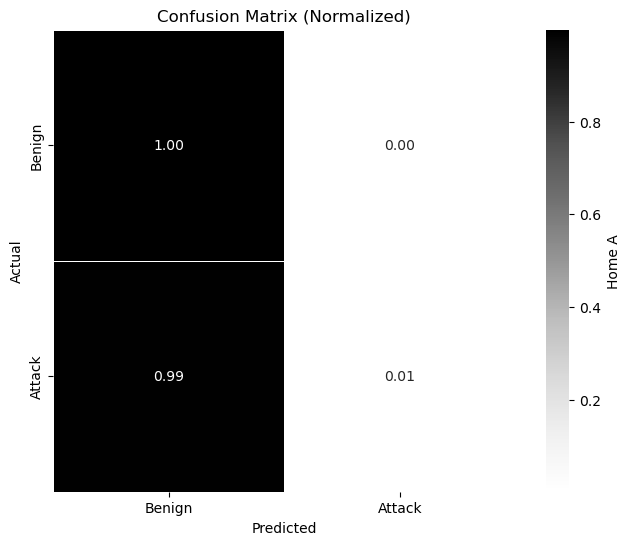

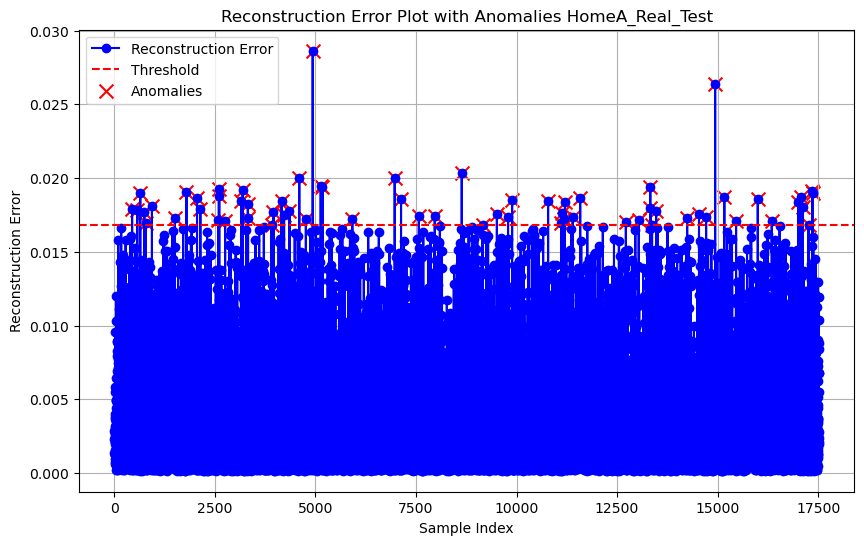

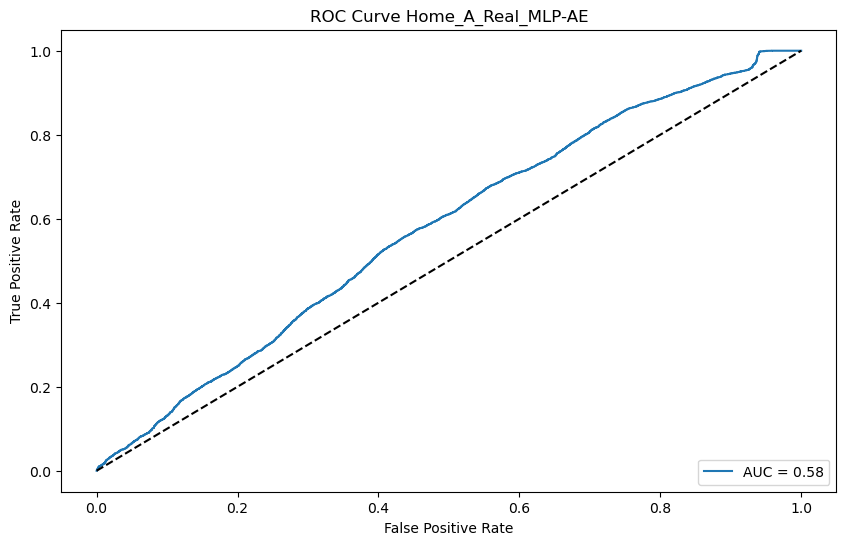

In [20]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot confusion matrix heatmap

#####################################################################
import seaborn as sns

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, anomalies)

# Normalize the confusion matrix
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create a DataFrame with column and index labels
# cm_df = pd.DataFrame(conf_matrix, columns=['Benign', 'Attack'], index=['Benign', 'Attack'])

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
# sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap='Greys', linewidths=0.5, square=True, cbar_kws={'label': 'Home A'}
sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
            cbar_kws={'label': 'Home A'},
            xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Normalized)')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_anomalies_real_cm.png',bbox_inches='tight')
# plt.savefig(f'Confusion_Matrix_{name}.png')  # Save with the model name
plt.show()

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeA_Real_Test')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_anomalies_real.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_anomalies_real.eps',bbox_inches='tight')
plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Home_A_Real_MLP-AE')
plt.legend(loc='lower right')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_ROC_real.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-A_ROC_real.eps',bbox_inches='tight')
plt.show()


### Model - 2 for Home A (Simulated and Real Test Set)
#### Implementing hidden-dim layers

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load and preprocess data
data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_df = pd.read_csv(data_path)

# Extract features (X) and target labels (y) from the loaded data
X = data_df.drop(columns=["Label"])  # Drop the label column
y = data_df["Label"]

# Split the data into training and test sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X)
#X_test_scaled = scaler.transform(X_test)

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train_scaled shape:", X_train.shape)
#print("y_train shape:", y_train.shape)


X shape: (35040, 1380)
y shape: (35040,)
X_train_scaled shape: (35040, 1380)


In [22]:
# Define the autoencoder model with deep layers
input_dim = X_train_scaled.shape[1]
encoding_dim = 64
hidden_dim = 32  # This is the variable you want to use

input_layer = Input(shape=(input_dim,))
encoder_hidden_layer = Dense(hidden_dim, activation='relu')(input_layer)  # Hidden layer
encoder_layer1 = Dense(encoding_dim * 2, activation='relu')(encoder_hidden_layer)
encoder_layer2 = Dense(encoding_dim, activation='relu')(encoder_layer1)
decoder_layer2 = Dense(encoding_dim * 2, activation='relu')(encoder_layer2)
decoder_layer1 = Dense(input_dim, activation='sigmoid')(decoder_layer2)

autoencoder = Model(input_layer, decoder_layer1)
autoencoder.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder on the training set
autoencoder.fit(X_train_scaled, X_train_scaled,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.1,  # Using a portion of training data for validation
                callbacks=[early_stopping])  # Adding the early stopping callback


Epoch 1/100
986/986 [==============================] - 5s 4ms/step - loss: 0.0185 - val_loss: 0.0107
Epoch 2/100
986/986 [==============================] - 5s 5ms/step - loss: 0.0078 - val_loss: 0.0062
Epoch 3/100
986/986 [==============================] - 5s 5ms/step - loss: 0.0055 - val_loss: 0.0053
Epoch 4/100
986/986 [==============================] - 4s 5ms/step - loss: 0.0047 - val_loss: 0.0046
Epoch 5/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0043 - val_loss: 0.0043
Epoch 6/100
986/986 [==============================] - 5s 5ms/step - loss: 0.0040 - val_loss: 0.0041
Epoch 7/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0039 - val_loss: 0.0040
Epoch 8/100
986/986 [==============================] - 5s 5ms/step - loss: 0.0037 - val_loss: 0.0039
Epoch 9/100
986/986 [==============================] - 5s 5ms/step - loss: 0.0036 - val_loss: 0.0037
Epoch 10/100
986/986 [==============================] - 5s 5ms/step - loss: 0.0036 - val_lo

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 1380)]            0         
                                                                 
 dense_4 (Dense)             (None, 32)                44192     
                                                                 
 dense_5 (Dense)             (None, 128)               4224      
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dense_7 (Dense)             (None, 128)               8320      
                                                                 
 dense_8 (Dense)             (None, 1380)              178020    
                                                                 
Total params: 243,012
Trainable params: 243,012
Non-trainab

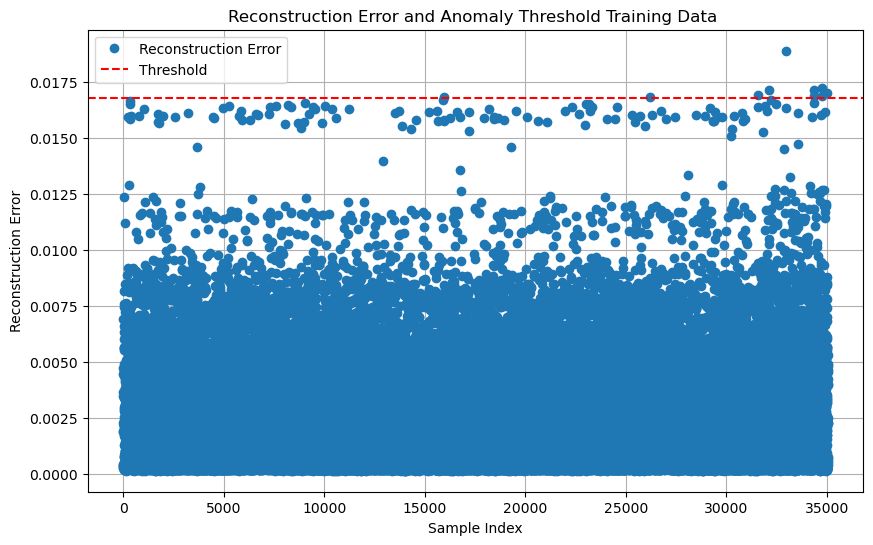

In [23]:
# Print the model summary
autoencoder.summary()

# Calculate reconstruction error for test data
train_predictions = autoencoder.predict(X_train_scaled)
reconstruction_error = np.mean(np.square(X_train_scaled - train_predictions), axis=1)

# Print reconstruction errors
print("Reconstruction Errors:")
print(reconstruction_error)

# Calculate threshold using Median Absolute Deviation (MAD)
median = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median))
threshold = median + (9 * mad)  # Adjust the multiplier as needed

print("Threshold:", threshold)

# Print and save the trained autoencoder model
model_path = "trained_autoencoder_model.h5"
autoencoder.save(model_path)
print("Model saved at:", model_path)

# Save the threshold
threshold_path = "trained_threshold.npy"
np.save(threshold_path, threshold)
print("Threshold saved at:", threshold_path)

# Visualize the reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Anomaly Threshold Training Data ')
plt.legend()
plt.grid()
plt.show()


In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
# y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
# y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)


 1/10 [==>...........................] - ETA: 0s

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


10/10 [==============================] - 0s 2ms/step
Threshold saved at: 0.016759469951620073
Anomalous Data Indices:
[  9  21  22  28  30  32  37  42  57  62  63  72  73  74  77  85  86  91
  95 102 107 115 131 137 159 169 174 177 189 190 193 200 228 229 247 248
 255 256 266 269 286]


In [25]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

Accuracy: 0.5896551724137931
Precision: 0.8048780487804879
Recall: 0.22916666666666666
TNR: 0.9452054794520548
FPR: 0.0547945205479452
FNR: 0.7708333333333334
F1 Score: 0.3567567567567567
ROC AUC: 0.7555175038051751


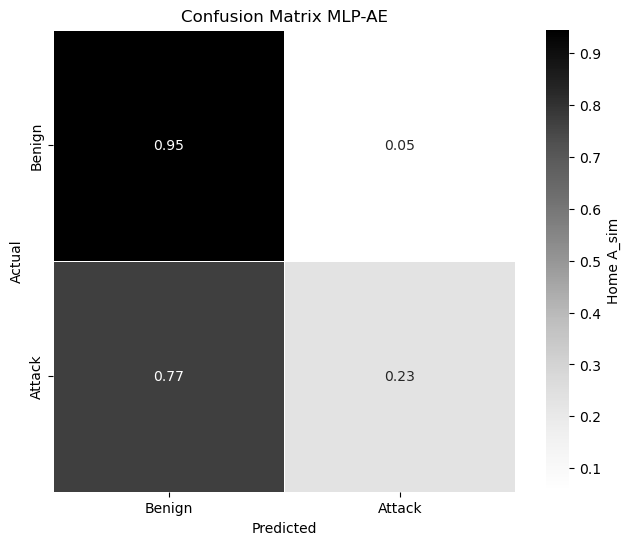

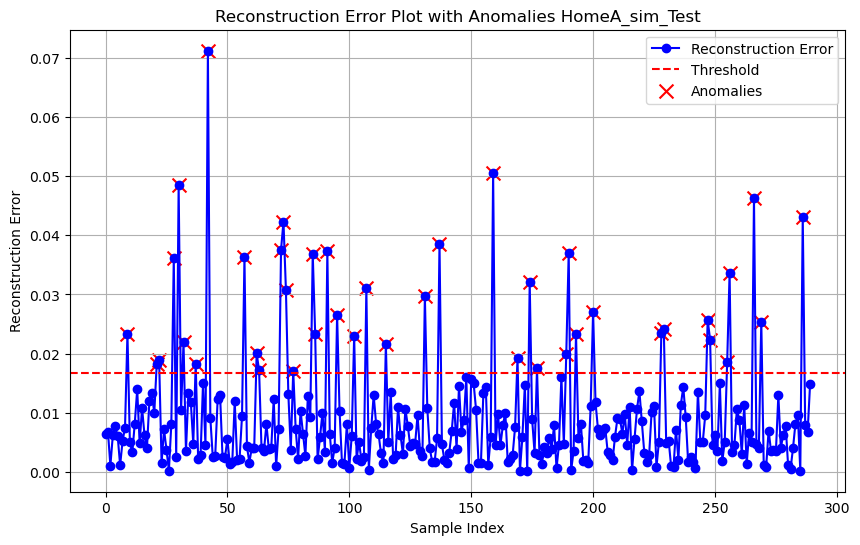

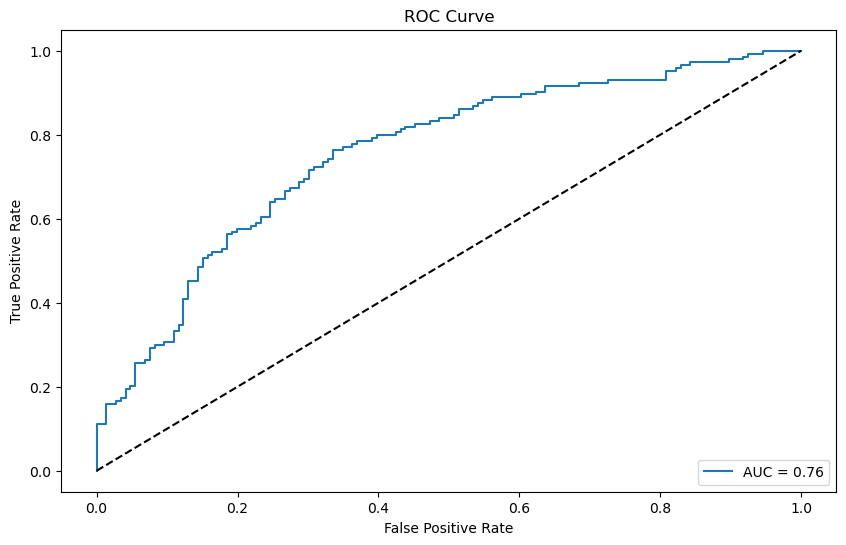

In [26]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

import seaborn as sns

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, anomalies)

# Normalize the confusion matrix
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create a DataFrame with column and index labels
# cm_df = pd.DataFrame(conf_matrix, columns=['Benign', 'Attack'], index=['Benign', 'Attack'])

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
# sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap='Greys', linewidths=0.5, square=True, cbar_kws={'label': 'Home A'}
sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
            cbar_kws={'label': 'Home A_sim'},
            xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix MLP-AE')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_anomalies_sim_dlaye_cm.png',bbox_inches='tight')
# plt.savefig(f'Confusion_Matrix_{name}.png')  # Save with the model name
plt.show()

# Plot confusion matrix heatmap
# plt.figure(figsize=(8, 6))
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Gray', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.title('Confusion Matrix')
# plt.show()

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeA_sim_Test')
plt.legend()
plt.grid()

plt.show()


# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_real_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
# y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
# y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

# Convert anomalies to binary format
#anomalies_binary = np.where(anomalies, 1, 0)

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


548/548 [==============================] - 2s 3ms/step
Threshold saved at: 0.016759469951620073
Anomalous Data Indices:
[   18    44    83 ... 17499 17510 17516]


In [28]:
test_reconstruction_error

array([0.00891478, 0.0032135 , 0.00180357, ..., 0.00317972, 0.01138061,
       0.01611474])

In [29]:
y_test

array([1, 0, 0, ..., 1, 1, 1], dtype=int64)

In [30]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

Accuracy: 0.5086187214611873
Precision: 0.5723873441994247
Recall: 0.06815068493150685
TNR: 0.9490867579908676
FPR: 0.05091324200913242
FNR: 0.9318493150684931
F1 Score: 0.12179944914821993
ROC AUC: 0.5888437219824441


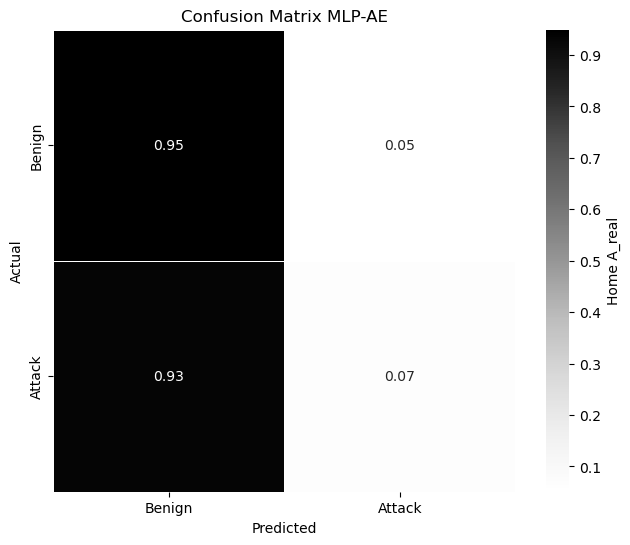

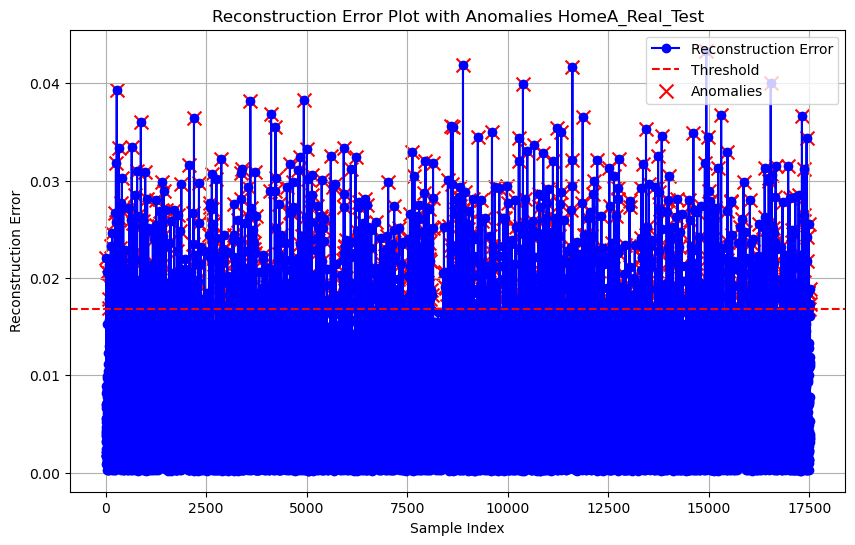

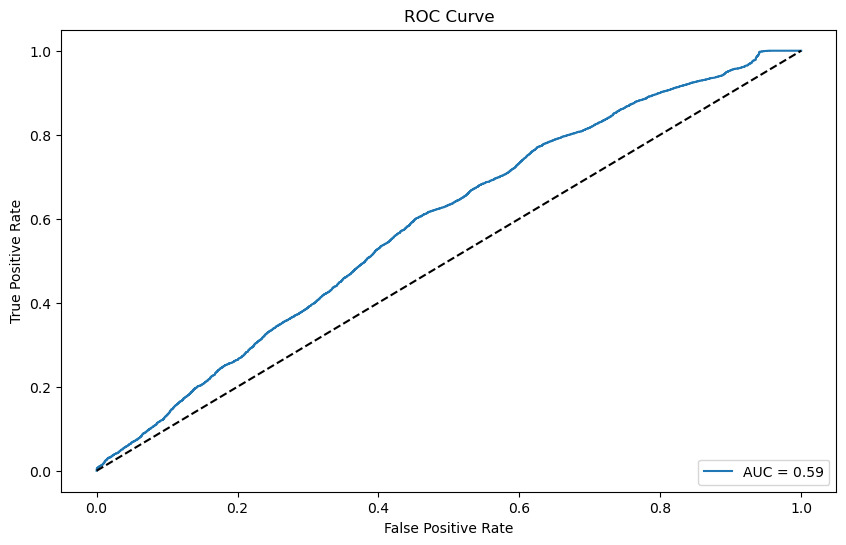

In [31]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

import seaborn as sns

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, anomalies)

# Normalize the confusion matrix
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create a DataFrame with column and index labels
# cm_df = pd.DataFrame(conf_matrix, columns=['Benign', 'Attack'], index=['Benign', 'Attack'])

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
# sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap='Greys', linewidths=0.5, square=True, cbar_kws={'label': 'Home A'}
sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
            cbar_kws={'label': 'Home A_real'},
            xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix MLP-AE')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\mlp-A_anomalies_real_dlayer_cm.png',bbox_inches='tight')
# plt.savefig(f'Confusion_Matrix_{name}.png')  # Save with the model name
plt.show()

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeA_Real_Test')
plt.legend()
plt.grid()

plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train_sim = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test_sim = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

data_path_train_real = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test_real = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_real_test.csv"

# Load train and test data for simulated and real datasets
train_data_sim = pd.read_csv(data_path_train_sim)
test_data_sim = pd.read_csv(data_path_test_sim)

train_data_real = pd.read_csv(data_path_train_real)
test_data_real = pd.read_csv(data_path_test_real)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train_sim = train_data_sim.drop(columns=['Label']).values
y_train_sim = train_data_sim['Label'].values
X_test_sim = test_data_sim.drop(columns=['Label']).values
y_test_sim = test_data_sim['Label'].values

#print(y_test_sim)

X_train_real = train_data_real.drop(columns=['Label']).values
y_train_real = train_data_real['Label'].values
X_test_real = test_data_real.drop(columns=['Label']).values
y_test_real = test_data_real['Label'].values

# Data preprocessing
scaler = MinMaxScaler()
X_train_scaled_sim = scaler.fit_transform(X_train_sim)
X_test_scaled_sim = scaler.transform(X_test_sim)

X_train_scaled_real = scaler.fit_transform(X_train_real)
X_test_scaled_real = scaler.transform(X_test_real)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions_sim = autoencoder.predict(X_test_scaled_sim)
test_reconstruction_error_sim = np.mean(np.square(X_test_scaled_sim - test_predictions_sim), axis=1)

test_predictions_real = autoencoder.predict(X_test_scaled_real)
test_reconstruction_error_real = np.mean(np.square(X_test_scaled_real - test_predictions_real), axis=1)

# Load the saved threshold
threshold_sim = np.load("trained_threshold.npy")
threshold_real = np.load("trained_threshold.npy")
print("Threshold saved at (simulated data):", threshold_sim)
print("Threshold saved at (real data):", threshold_real)

# Classify anomalies based on the threshold
anomalies_sim = test_reconstruction_error_sim > threshold_sim
anomalies_real = test_reconstruction_error_real > threshold_real


548/548 [==============================] - 1s 1ms/step
Threshold saved at (simulated data): 0.016759469951620073
Threshold saved at (real data): 0.016759469951620073


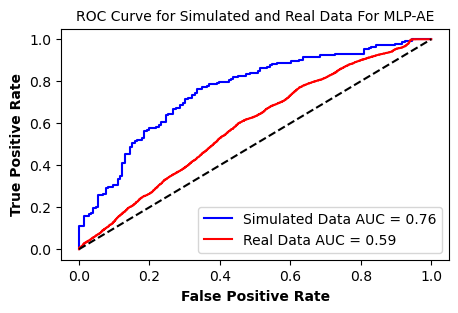

In [3]:
# Compute ROC curve and AUC for both datasets
fpr_curve_sim, tpr_curve_sim, _ = roc_curve(y_test_sim, test_reconstruction_error_sim)
roc_auc_sim = roc_auc_score(y_test_sim, test_reconstruction_error_sim)

fpr_curve_real, tpr_curve_real, _ = roc_curve(y_test_real, test_reconstruction_error_real)
roc_auc_real = roc_auc_score(y_test_real, test_reconstruction_error_real)

# Plot ROC curves for both datasets on the same plot
plt.figure(figsize=(5, 3))
plt.plot(fpr_curve_sim, tpr_curve_sim, label=f'Simulated Data AUC = {roc_auc_sim:.2f}', color='b')
plt.plot(fpr_curve_real, tpr_curve_real, label=f'Real Data AUC = {roc_auc_real:.2f}', color='r')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate', fontsize=10, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=10, fontweight='bold')
plt.title('ROC Curve for Simulated and Real Data For MLP-AE', fontsize=10)
plt.legend(loc='lower right', fontsize=10)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\MLP-AE_roc_sim_real.png', bbox_inches='tight')
plt.show()


548/548 [==============================] - 1s 884us/step


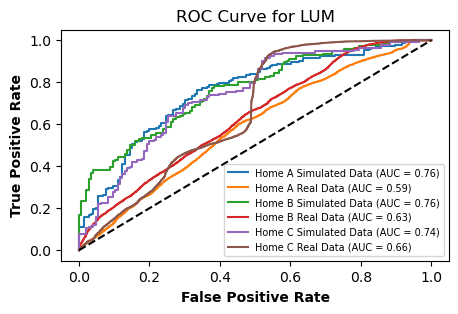

In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve, roc_auc_score
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

def evaluate_and_plot_roc(data_path_train, data_path_test, model_path, threshold_path, label):
    # Load train and test data
    train_data = pd.read_csv(data_path_train)
    test_data = pd.read_csv(data_path_test)

    # Extract features (X) and labels (y) from both datasets
    X_train = train_data.drop(columns=['Label']).values
    y_train = train_data['Label'].values
    X_test = test_data.drop(columns=['Label']).values
    y_test = test_data['Label'].values

    # Data preprocessing (scaling)
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Load the trained autoencoder model
    autoencoder = load_model(model_path)

    # Calculate reconstruction error for test data
    test_predictions = autoencoder.predict(X_test_scaled)
    test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

    # Load the saved threshold
    threshold = np.load(threshold_path)

    # Classify anomalies based on the threshold
    anomalies = test_reconstruction_error > threshold

    # Calculate ROC curve and AUC
    fpr_curve, tpr_curve, _ = roc_curve(y_test, test_reconstruction_error)
    roc_auc = roc_auc_score(y_test, test_reconstruction_error)

    # Plot ROC curve
    plt.plot(fpr_curve, tpr_curve, label=f'{label} (AUC = {roc_auc:.2f})')

# Define a list of dataset configurations
datasets = [
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv",
        'model_path': "trained_autoencoder_model.h5",
        'threshold_path': "trained_threshold.npy",
        'label': "Home A Simulated Data"
    },
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_real_test.csv",
        'model_path': "trained_autoencoder_model.h5",
        'threshold_path': "trained_threshold.npy",
        'label': "Home A Real Data"
    },
    # Add configurations for the other datasets here
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_sim_test.csv",
        'model_path': "trained_autoencoder_model.h5",
        'threshold_path': "trained_threshold.npy",
        'label': "Home B Simulated Data"
    },
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_real_test.csv",
        'model_path': "trained_autoencoder_model.h5",
        'threshold_path': "trained_threshold.npy",
        'label': "Home B Real Data"
    },
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_sim_test.csv",
        'model_path': "trained_autoencoder_model.h5",
        'threshold_path': "trained_threshold.npy",
        'label': "Home C Simulated Data"
    },
    {
        'train_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv",
        'test_path': "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_real_test.csv",
        'model_path': "trained_autoencoder_model.h5",
        'threshold_path': "trained_threshold.npy",
        'label': "Home C Real Data"
    }
]

# Initialize the scaler
scaler = MinMaxScaler()

# Create a figure for the ROC curve
plt.figure(figsize=(5, 3))

# Loop through each dataset and plot ROC curve
for dataset in datasets:
    evaluate_and_plot_roc(dataset['train_path'], dataset['test_path'], dataset['model_path'], dataset['threshold_path'], dataset['label'])

# Plot the diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--')

# Customize the plot
plt.xlabel('False Positive Rate', fontsize=10, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=10, fontweight='bold')
plt.title('ROC Curve for LUM')
plt.legend(loc='lower right', fontsize=7)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\LUM.png', bbox_inches='tight')
# Show the plot or save it to a file
plt.show()
